# LDA
* Vectorization with BoW
* LDA algorithm
* Evaluation with perplexity and coherence
* Visualization with PCA & UMAP <br>
--> Present topic clusters and top words for optimal k

In [40]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import CoherenceModel
from gensim import corpora
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

In [41]:
df = pd.read_pickle("data/preprocessed_data.pkl")
df

,id,question,link_flair_css_class,link_flair_text,clean_text,tokens
0,421zyl,How is time defined at the big bang?,physics,Physics,time define big bang,"[time, define, big, bang]"
1,4r857d,UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,ufo good scientific explanation atmospherical ...,"[ufo, good, scientific, explanation, atmospher..."
2,4r0zwj,It's a commonly known fact that metals oxidize...,chem,Chemistry,commonly know fact metal oxidize possible dize...,"[commonly, know, fact, metal, oxidize, possibl..."
4,4r191k,Geoscientists: Is there any current research i...,geo,Planetary Sci.,geoscientist current research project shortfal...,"[geoscientist, current, research, project, sho..."
5,4r18ga,"Why are there so many ""accident"" babies yet so...",bio,Biology,accident baby people struggle conceive,"[accident, baby, people, struggle, conceive]"
...,...,...,...,...,...,...
612662,ry6rh0,2 doses of vaccines protect against severe ill...,med,COVID-19,dos vaccine protect severe illness infection m...,"[dos, vaccine, protect, severe, illness, infec..."
612663,ry6of6,Dentists! I've got a question for you: why do ...,med,Medicine,dentist get question dentist labeling advise c...,"[dentist, get, question, dentist, labeling, ad..."
612665,ry6nle,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,don ocean salty time,"[don, ocean, salty, time]"
612666,rwkxsm,Would tracing paper be classed as translucent ...,physics,Physics,trace paper class translucent transparent like...,"[trace, paper, class, translucent, transparent..."


## BoW

In [42]:
# Create vectorizer
vectorizer = CountVectorizer(max_features=20000, min_df=3, max_df=0.9, stop_words='english')  # remove very rare or overly common words, limit features and specify stopwords

# Fit and transform 'clean text'
X = vectorizer.fit_transform(df["clean_text"])

# Vocabulary size
print(len(vectorizer.vocabulary_))
# Feature names
print(vectorizer.get_feature_names_out())
# Sparse feature matrix
print(X)

20000
['aav' 'abandon' 'abate' ... 'zuckerberg' 'zygote' 'zyklon']
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3569011 stored elements and shape (506202, 20000)>
  Coords	Values
  (0, 18030)	1
  (0, 4445)	1
  (0, 1707)	1
  (0, 1446)	1
  (1, 18612)	1
  (1, 7571)	1
  (1, 15635)	1
  (1, 6317)	1
  (1, 6140)	1
  (1, 10996)	1
  (2, 3400)	1
  (2, 9806)	1
  (2, 6421)	1
  (2, 10973)	1
  (2, 12644)	1
  (2, 13567)	1
  (2, 7282)	1
  (3, 4178)	1
  (3, 14917)	1
  (3, 13884)	1
  (3, 9730)	1
  (3, 11161)	1
  (3, 5643)	1
  (3, 4356)	1
  (4, 96)	1
  :	:
  (506198, 15304)	1
  (506198, 13757)	1
  (506198, 365)	1
  (506198, 4557)	2
  (506198, 11506)	1
  (506198, 291)	1
  (506198, 2969)	1
  (506199, 18030)	1
  (506199, 5159)	1
  (506199, 12238)	1
  (506199, 15452)	1
  (506200, 8255)	1
  (506200, 6392)	1
  (506200, 10164)	1
  (506200, 21)	1
  (506200, 12734)	1
  (506200, 3093)	1
  (506200, 18330)	1
  (506200, 18313)	1
  (506200, 18225)	1
  (506201, 5431)	1
  (506201, 13208)	1
  (506201, 15826

## LDA

### Prototype

In [24]:
n_topics = 10

lda = LatentDirichletAllocation(
    n_components=n_topics,
    learning_method="online",
    batch_size=4096,
    random_state=42,
    max_iter=10
)

lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",10
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'online'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",4096
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [25]:
def print_topics(model, vectorizer, n_top_words=10):
    words = vectorizer.get_feature_names_out()

    for topic_idx, topic in enumerate(model.components_):
        top_words = [words[i] for i in topic.argsort()[-n_top_words:]]
        print(f"Topic {topic_idx}: {top_words}")

print_topics(lda, vectorizer)

Topic 0: ['body', 'hot', 'high', 'drink', 'level', 'heat', 'cold', 'temperature', 'air', 'water']
Topic 1: ['calculate', 'red', 'hold', 'blue', 'determine', 'eye', 'turn', 'help', 'hand', 'color']
Topic 2: ['good', 'know', 'like', 'feel', 'sleep', 'science', 'person', 'life', 'people', 'brain']
Topic 3: ['long', 'taste', 'body', 'bad', 'like', 'burn', 'man', 'smell', 'eat', 'food']
Topic 4: ['earth', 'object', 'year', 'travel', 'space', 'fast', 'change', 'speed', 'light', 'time']
Topic 5: ['gravitational', 'pain', 'radiation', 'muscle', 'cause', 'force', 'skin', 'wave', 'body', 'sound']
Topic 6: ['moon', 'star', 'happen', 'sun', 'hole', 'like', 'look', 'black', 'planet', 'earth']
Topic 7: ['atom', 'particle', 'possible', 'theory', 'create', 'exist', 'big', 'energy', 'matter', 'universe']
Topic 8: ['different', 'people', 'evolve', 'like', 'specie', 'virus', 'vaccine', 'animal', 'covid', 'human']
Topic 9: ['health', 'field', 'possible', 'dna', 'car', 'nuclear', 'energy', 'power', 'use', 

In [26]:
doc_topic = lda.transform(X)

In [29]:
df["dominant_topic"] = np.argmax(doc_topic, axis=1)

In [30]:
for topic in range(n_topics):
    print(f"\nTopic {topic}")
    print(df[df["dominant_topic"] == topic]["clean_text"].head(3))


Topic 0
11                  tendon ligament degenerate lack use
20            dirt accumulate ancient year old building
31    food generally taste well hot ice cream taste ...
Name: clean_text, dtype: str

Topic 1
4     geoscientist current research project shortfal...
8     hold breath long underwater lung scientific ti...
10    possible track position visible star determine...
Name: clean_text, dtype: str

Topic 2
1     ufo good scientific explanation atmospherical ...
17     chemistry important sure daily omega daily omega
26    lay deep relaxed state eye close sleep scienti...
Name: clean_text, dtype: str

Topic 3
21                             std eat human penis cook
24    polystyrene bead gas chemical pillow tiny bead...
72                     chigger bite grow large area day
Name: clean_text, dtype: str

Topic 4
6     understand time dialate speed velocity near sp...
16    correlation general relativity quantum mechani...
19                 car travel foot frame video fast mph

### Finding the Best Value for *k*

In [43]:
texts = df["tokens"].tolist()
dictionary = corpora.Dictionary(texts)

def train_lda(k, X):
    lda = LatentDirichletAllocation(
        n_components=k,
        learning_method="online",
        max_iter=5,
        random_state=42
    )
    lda.fit(X)
    return lda

In [44]:
def evaluate_model(lda, X, vectorizer, texts, dictionary, top_n=10):

    # Perplexity
    perplexity = lda.perplexity(X)

    # Extract topics
    feature_names = np.array(vectorizer.get_feature_names_out())

    topics = []

    for topic in lda.components_:
        top_words = feature_names[topic.argsort()[-top_n:]]
        topics.append(list(top_words))

    # Coherence
    cm = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    coherence = cm.get_coherence()

    # Topic diversity
    all_topic_words = []

    for topic in topics:
        all_topic_words.extend(topic)

    diversity = len(set(all_topic_words)) / len(all_topic_words)

    return coherence, perplexity, diversity

In [45]:
# Broad range for k to find sensible range
k_values = range(5, 101, 5)

results = []

for k in k_values:
    print(f"Training LDA with k={k}")

    lda = train_lda(k, X)

    coherence, perplexity, diversity = evaluate_model(
    lda, X, vectorizer, texts, dictionary
    )

    results.append((k, coherence, perplexity, diversity))

Training LDA with k=5
Training LDA with k=10
Training LDA with k=15
Training LDA with k=20
Training LDA with k=25
Training LDA with k=30
Training LDA with k=35
Training LDA with k=40
Training LDA with k=45
Training LDA with k=50
Training LDA with k=55
Training LDA with k=60
Training LDA with k=65
Training LDA with k=70
Training LDA with k=75
Training LDA with k=80
Training LDA with k=85
Training LDA with k=90
Training LDA with k=95
Training LDA with k=100


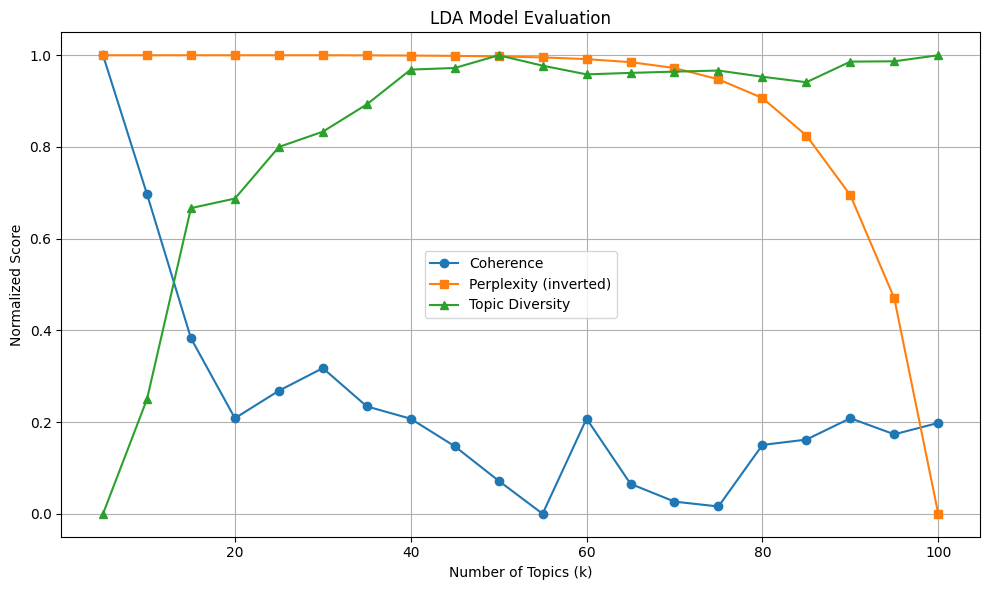

In [46]:
k_vals = [r[0] for r in results]

coherence = np.array([r[1] for r in results]).reshape(-1, 1)
perplexity = np.array([r[2] for r in results]).reshape(-1, 1)
diversity = np.array([r[3] for r in results]).reshape(-1, 1)

scaler = MinMaxScaler()

coherence_norm = scaler.fit_transform(coherence).flatten()

# Invert perplexity (lower score is better)
perplexity_norm = 1 - scaler.fit_transform(perplexity).flatten()

diversity_norm = scaler.fit_transform(diversity).flatten()

plt.figure(figsize=(10,6))

plt.plot(
    k_vals,
    coherence_norm,
    marker='o',
    label='Coherence'
)

plt.plot(
    k_vals,
    perplexity_norm,
    marker='s',
    label='Perplexity (inverted)'
)

plt.plot(
    k_vals,
    diversity_norm,
    marker='^',
    label='Topic Diversity'
)

plt.xlabel("Number of Topics (k)")
plt.ylabel("Normalized Score")
plt.title("LDA Model Evaluation")

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig('viz/LDA_evaluation_metrics.png', dpi=300)

plt.show()

Print metrics as table for comparison --> Evaluate to choose best k!

In [47]:
# Select best k
best_k = max(results, key=lambda x: x[1])[0]
print("Best k:", best_k)

Best k: 5


### Final Run with best *k*

In [48]:
final_lda = train_lda(best_k, X)

In [49]:
def show_topics(model, vectorizer, n_words=10):
    words = vectorizer.get_feature_names_out()

    for i, topic in enumerate(model.components_):
        top_words = [words[j] for j in topic.argsort()[-n_words:]]
        print(f"Topic {i}: {top_words}")

show_topics(final_lda, vectorizer)

Topic 0: ['cause', 'feel', 'effect', 'body', 'year', 'work', 'people', 'human', 'vaccine', 'covid']
Topic 1: ['exist', 'matter', 'level', 'know', 'air', 'help', 'change', 'create', 'high', 'come']
Topic 2: ['possible', 'thing', 'virus', 'look', 'life', 'planet', 'use', 'universe', 'earth', 'like']
Topic 3: ['earth', 'mass', 'gravity', 'body', 'happen', 'animal', 'need', 'energy', 'human', 'water']
Topic 4: ['fast', 'travel', 'hole', 'black', 'happen', 'space', 'speed', 'different', 'light', 'time']
